In [ ]:
!pip install pandas numpy matplotlib seaborn --quiet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def generate_unit_econ_data(n=500):
    np.random.seed(42)
    # Simulate basic inputs
    # ARPU between $10 and $200
    arpu = np.random.uniform(10, 200, size=n)
    # Churn rate between 1% and 10%
    churn = np.random.uniform(0.01, 0.10, size=n)
    # CAC between $50 and $500
    cac = np.random.uniform(50, 500, size=n)
    # New customers per month between 10 and 1000
    new_customers = np.random.randint(10, 1000, size=n)
    # MAU between 100 and 100000
    mau = np.random.randint(100, 100000, size=n)
    # Cash on hand between $10k and $1M
    cash = np.random.uniform(1e4, 1e6, size=n)
    # Monthly burn between $5k and $200k
    burn = np.random.uniform(5e3, 2e5, size=n)

    # Compute LTV and LTV:CAC
    ltv = arpu / churn
    ltvcac = ltv / cac

    # Build DataFrame
    df = pd.DataFrame({
        'ARPU': arpu,
        'Churn_Rate': churn,
        'CAC': cac,
        'New_Customers': new_customers,
        'MAU': mau,
        'Cash_on_Hand': cash,
        'Monthly_Burn': burn,
        'LTV': ltv,
        'LTV_CAC': ltvcac
    })
    return df

In [ ]:
def compute_unit_econ_score(df):
    # Normalization
    norm_ltvcac = (df['LTV_CAC'] / 3).clip(0, 1)
    norm_churn = (1 - df['Churn_Rate'] / 0.10).clip(0, 1)
    norm_mau = (df['MAU'] / 100000).clip(0, 1)

    # Weighted sum
    df['UnitEconScore'] = (
        0.5 * norm_ltvcac +
        0.25 * norm_churn +
        0.25 * norm_mau
    ) * 100

    return df

In [ ]:
def run_pipeline(n=500):
    df = generate_unit_econ_data(n)
    df = compute_unit_econ_score(df)

    print(f"✅ Dataset shape: {df.shape}")
    display(df.head())

    # Distribution of scores
    plt.figure(figsize=(8, 4))
    sns.histplot(df['UnitEconScore'], bins=30)
    plt.title('Distribution of Unit Economics Scores')
    plt.xlabel('Score (0-100)')
    plt.ylabel('Frequency')
    plt.show()

    # Scatter: LTV:CAC vs Score
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df['LTV_CAC'], y=df['UnitEconScore'])
    plt.title('LTV:CAC vs Unit Econ Score')
    plt.xlabel('LTV:CAC')
    plt.ylabel('Unit Econ Score')
    plt.show()

    # Scatter: Churn vs Score
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df['Churn_Rate'], y=df['UnitEconScore'])
    plt.title('Churn Rate vs Unit Econ Score')
    plt.xlabel('Churn Rate')
    plt.ylabel('Unit Econ Score')
    plt.show()

✅ Dataset shape: (500, 10)


,ARPU,Churn_Rate,CAC,New_Customers,MAU,Cash_on_Hand,Monthly_Burn,LTV,LTV_CAC,UnitEconScore
0,81.162623,0.072835,133.309818,825,70431,103210.391024,145359.333404,1114.342271,8.359041,74.399111
1,190.635718,0.058249,293.855426,459,10734,350226.560683,174052.026329,3272.790752,11.137418,63.121332
2,149.078849,0.037857,442.825626,463,4898,289606.589700,93519.635381,3937.896221,8.892657,66.760129
3,123.745112,0.083242,379.501199,933,22520,396821.081957,165179.238370,1486.578630,3.917191,59.819612
4,39.643542,0.071626,412.952517,638,29400,800360.746342,113158.182867,553.481268,1.340302,36.781923


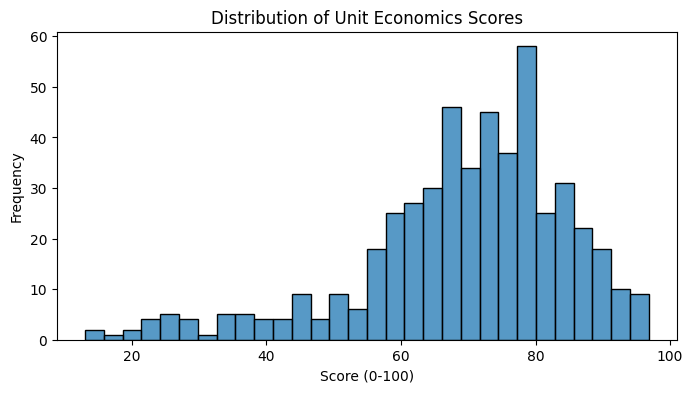

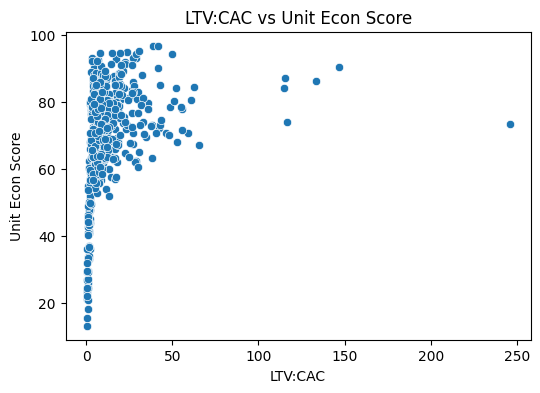

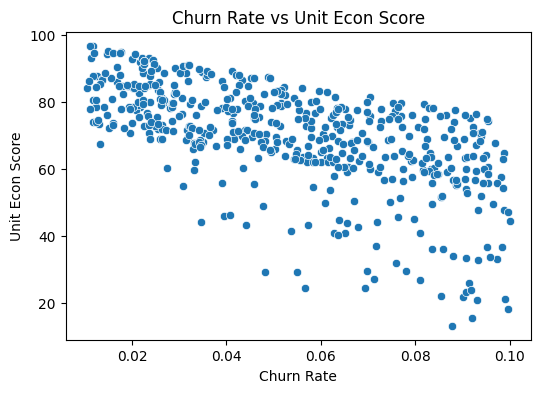

from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['ARPU'].plot(kind='hist', bins=20, title='ARPU')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Churn_Rate'].plot(kind='hist', bins=20, title='Churn_Rate')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['CAC'].plot(kind='hist', bins=20, title='CAC')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='index', y='ARPU', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['New_Customers']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('New_Customers')

from matplotlib import pyplot as plt
_df_12['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['ARPU'].plot(kind='line', figsize=(8, 4), title='ARPU')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Churn_Rate'].plot(kind='line', figsize=(8, 4), title='Churn_Rate')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['CAC'].plot(kind='line', figsize=(8, 4), title='CAC')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
run_pipeline()
